# US Accidents Severity Prediction — Model Optimization and Final Model Selection

This notebook represents **Stage 7 – Model Optimization and Final Model Selection**.

The objective is to improve the baseline models developed in Stage 6 by:

- tuning important hyperparameters,
- investigating class imbalance handling,
- comparing optimized models with baseline models,
- evaluating models using the validation set,
- and selecting the final model based on appropriate evaluation metrics.

The test dataset is kept completely separate and will only be used for the final evaluation after model selection.

## 1. Optimization Strategy

The Stage 6 baseline results showed that Random Forest and XGBoost provided the strongest overall performance.

Therefore, Stage 7 focuses optimization on:

1. Random Forest
2. XGBoost

The main optimization metric is **Macro F1-score** because the target variable is highly imbalanced.

Accuracy alone is not sufficient because Severity 2 represents the majority of accidents, while Severity 1 and Severity 4 are much less frequent.

We will also investigate class weighting to determine whether giving greater importance to minority classes improves balanced classification performance.

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_DIR = "../data"
REPORT_DIR = "../outputs/reports"
FIGURE_DIR = "../outputs/figures"

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Final Modeling Dataset

The final datasets were produced during Stage 4 after:

- missing-value treatment,
- invalid-value treatment,
- categorical encoding,
- temporal feature engineering,
- numerical transformations,
- and feature selection.

The target variable is `Severity`.

The test dataset remains untouched during optimization.

In [3]:
TRAIN_FILE = os.path.join(DATA_DIR, "train_final.csv")
TEST_FILE = os.path.join(DATA_DIR, "test_final.csv")

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

X = train_df.drop(columns=["Severity"])
y = train_df["Severity"]

X_test = test_df.drop(columns=["Severity"])
y_test = test_df["Severity"]

print("\nX:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training shape: (799673, 139)
Testing shape : (199919, 139)

X: (799673, 138)
y: (799673,)
X_test: (199919, 138)
y_test: (199919,)


## 3. Create the Model Training and Validation Sets

The training dataset is divided into:

- 80% model-training data
- 20% validation data

Stratification is used so that the Severity distribution remains approximately the same in both sets.

The validation set is used for model comparison and optimization.

The final test set is not used at this stage.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Model-training set:", X_train.shape)
print("Validation set:", X_val.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True).sort_index())

Model-training set: (639738, 138)
Validation set: (159935, 138)

Training class distribution:
Severity
1    0.008616
2    0.796460
3    0.168750
4    0.026173
Name: proportion, dtype: float64

Validation class distribution:
Severity
1    0.008616
2    0.796461
3    0.168750
4    0.026173
Name: proportion, dtype: float64


## 4. Handle the Computational Cost of Hyperparameter Search

The training dataset contains hundreds of thousands of records.

Running an extensive hyperparameter search on the entire dataset would require substantial computation time.

Therefore, a stratified optimization subset is created from the model-training data.

The subset is used only to identify promising hyperparameter configurations.

After selecting the best configuration, the optimized model will be retrained using the full model-training dataset and evaluated on the validation set.

This keeps the optimization process computationally manageable while preserving the class distribution.

In [5]:
OPTIMIZATION_SIZE = 200_000

if len(X_train) > OPTIMIZATION_SIZE:
    X_opt, _, y_opt, _ = train_test_split(
        X_train,
        y_train,
        train_size=OPTIMIZATION_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    X_opt = X_train.copy()
    y_opt = y_train.copy()

print("Optimization subset:", X_opt.shape)
print("\nOptimization class distribution:")
print(y_opt.value_counts(normalize=True).sort_index())

Optimization subset: (200000, 138)

Optimization class distribution:
Severity
1    0.008615
2    0.796460
3    0.168750
4    0.026175
Name: proportion, dtype: float64


## 5. Random Forest Hyperparameter Optimization

Random Forest performed strongly during Stage 6.

The optimization will investigate parameters that control:

- number of trees,
- maximum tree depth,
- minimum samples required for splitting,
- minimum samples required at leaf nodes,
- number of features considered at each split,
- and class weighting.

`class_weight="balanced"` is included because the Severity classes are highly imbalanced.

Randomized search is used instead of testing every possible combination because the parameter space can become computationally expensive.

In [6]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_dist = {
    "n_estimators": [150, 250, 350],
    "max_depth": [None, 15, 25, 35],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=2,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

rf_start = time.time()

rf_search.fit(X_opt, y_opt)

rf_search_time = time.time() - rf_start

print("\nRandom Forest optimization completed.")
print("Optimization time:", round(rf_search_time, 2), "seconds")
print("\nBest parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(rf_search.best_score_, 4))

Fitting 2 folds for each of 8 candidates, totalling 16 fits

Random Forest optimization completed.
Optimization time: 141.84 seconds

Best parameters:
{'n_estimators': 350, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 35, 'class_weight': 'balanced'}

Best cross-validation Macro F1:
0.6447


## 6. Evaluate the Optimized Random Forest

The best Random Forest configuration identified during randomized search is retrained using the complete model-training dataset.

It is then evaluated on the validation set.

This provides a fair comparison with the Stage 6 baseline Random Forest.

In [7]:
best_rf = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_train_start = time.time()

best_rf.fit(X_train, y_train)

rf_train_time = time.time() - rf_train_start

rf_val_pred = best_rf.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_precision = precision_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_recall = recall_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_macro_f1 = f1_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_weighted_f1 = f1_score(
    y_val, rf_val_pred, average="weighted", zero_division=0
)

print("Optimized Random Forest")
print("-----------------------")
print("Training time:", round(rf_train_time, 2), "seconds")
print("Accuracy:", round(rf_accuracy, 4))
print("Macro Precision:", round(rf_precision, 4))
print("Macro Recall:", round(rf_recall, 4))
print("Macro F1:", round(rf_macro_f1, 4))
print("Weighted F1:", round(rf_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, rf_val_pred, zero_division=0))

Optimized Random Forest
-----------------------
Training time: 86.29 seconds
Accuracy: 0.8526
Macro Precision: 0.6084
Macro Recall: 0.7825
Macro F1: 0.6721
Weighted F1: 0.8628

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.85      0.62      1378
           2       0.96      0.86      0.91    127382
           3       0.62      0.88      0.73     26989
           4       0.36      0.54      0.43      4186

    accuracy                           0.85    159935
   macro avg       0.61      0.78      0.67    159935
weighted avg       0.89      0.85      0.86    159935



## 7. XGBoost Hyperparameter Optimization

XGBoost was the second strongest baseline model in Stage 6.

The optimization investigates:

- number of boosting trees,
- learning rate,
- maximum tree depth,
- minimum child weight,
- subsampling,
- column subsampling,
- and regularization.

The objective is to improve Macro F1 while maintaining good overall predictive performance.

In [8]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_param_dist = {
    "n_estimators": [150, 250, 350],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=2,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

xgb_start = time.time()

xgb_search.fit(X_opt, y_opt - 1)

xgb_search_time = time.time() - xgb_start

print("\nXGBoost optimization completed.")
print("Optimization time:", round(xgb_search_time, 2), "seconds")

print("\nBest parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(xgb_search.best_score_, 4))

Fitting 2 folds for each of 8 candidates, totalling 16 fits

XGBoost optimization completed.
Optimization time: 123.1 seconds

Best parameters:
{'subsample': 1.0, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best cross-validation Macro F1:
0.6557


## 8. Evaluate the Optimized XGBoost Model

The best XGBoost configuration identified during randomized search is retrained using the complete model-training dataset.

Predictions are converted back from the internal 0–3 representation to the original Severity 1–4 labels before calculating the evaluation metrics.

In [9]:
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_train_start = time.time()

best_xgb.fit(X_train, y_train - 1)

xgb_train_time = time.time() - xgb_train_start

xgb_val_pred = best_xgb.predict(X_val) + 1

xgb_accuracy = accuracy_score(y_val, xgb_val_pred)
xgb_precision = precision_score(
    y_val, xgb_val_pred, average="macro", zero_division=0
)
xgb_recall = recall_score(
    y_val, xgb_val_pred, average="macro", zero_division=0
)
xgb_macro_f1 = f1_score(
    y_val, xgb_val_pred, average="macro", zero_division=0
)
xgb_weighted_f1 = f1_score(
    y_val, xgb_val_pred, average="weighted", zero_division=0
)

print("Optimized XGBoost")
print("-----------------")
print("Training time:", round(xgb_train_time, 2), "seconds")
print("Accuracy:", round(xgb_accuracy, 4))
print("Macro Precision:", round(xgb_precision, 4))
print("Macro Recall:", round(xgb_recall, 4))
print("Macro F1:", round(xgb_macro_f1, 4))
print("Weighted F1:", round(xgb_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, xgb_val_pred, zero_division=0))

Optimized XGBoost
-----------------
Training time: 55.07 seconds
Accuracy: 0.8991
Macro Precision: 0.7838
Macro Recall: 0.624
Macro F1: 0.675
Weighted F1: 0.8929

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.55      0.63      1378
           2       0.92      0.96      0.94    127382
           3       0.79      0.73      0.76     26989
           4       0.69      0.25      0.37      4186

    accuracy                           0.90    159935
   macro avg       0.78      0.62      0.68    159935
weighted avg       0.89      0.90      0.89    159935



## 9. Compare Baseline and Optimized Models

The Stage 6 baseline results are compared with the optimized Random Forest and XGBoost models.

Macro F1 is given particular importance because it gives equal importance to all Severity classes and therefore provides a better indication of performance under class imbalance.

In [23]:
baseline_results = pd.read_csv(f"{REPORT_DIR}/stage6_baseline_model_results.csv")

rf_baseline = baseline_results[baseline_results["Model"] == "Random Forest"].iloc[0]
xgb_baseline = baseline_results[baseline_results["Model"] == "XGBoost"].iloc[0]

comparison = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "Accuracy": rf_baseline["Accuracy"],
        "Macro Precision": rf_baseline["Macro Precision"],
        "Macro Recall": rf_baseline["Macro Recall"],
        "Macro F1": rf_baseline["Macro F1"],
        "Weighted F1": rf_baseline["Weighted F1"]
    },
    {
        "Model": "XGBoost - Baseline",
        "Accuracy": xgb_baseline["Accuracy"],
        "Macro Precision": xgb_baseline["Macro Precision"],
        "Macro Recall": xgb_baseline["Macro Recall"],
        "Macro F1": xgb_baseline["Macro F1"],
        "Weighted F1": xgb_baseline["Weighted F1"]
    },
    {
        "Model": "Random Forest - Optimized",
        "Accuracy": rf_accuracy, "Macro Precision": rf_precision,
        "Macro Recall": rf_recall, "Macro F1": rf_macro_f1, "Weighted F1": rf_weighted_f1
    },
    {
        "Model": "XGBoost - Optimized",
        "Accuracy": xgb_accuracy, "Macro Precision": xgb_precision,
        "Macro Recall": xgb_recall, "Macro F1": xgb_macro_f1, "Weighted F1": xgb_weighted_f1
    }
])

comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(comparison)

comparison.to_csv(
    f"{REPORT_DIR}/model_optimization_comparison.csv",
    index=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost - Optimized,0.899122,0.783811,0.624010,0.675022,0.892873
1,Random Forest - Optimized,0.852596,0.608439,0.782500,0.672069,0.862801
2,XGBoost - Baseline,0.888849,0.778233,0.592062,0.648264,0.881168
3,Random Forest - Baseline,0.898340,0.814369,0.578973,0.647497,0.889964


## 10. Optimization Improvement

This section measures whether hyperparameter tuning improved Macro F1 compared with the Stage 6 baseline.

A positive improvement indicates that optimization improved balanced performance across the Severity classes.

In [24]:
rf_improvement = rf_macro_f1 - rf_baseline["Macro F1"]
xgb_improvement = xgb_macro_f1 - xgb_baseline["Macro F1"]

improvement = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Baseline Macro F1": [rf_baseline["Macro F1"], xgb_baseline["Macro F1"]],
    "Optimized Macro F1": [rf_macro_f1, xgb_macro_f1],
    "Macro F1 Improvement": [rf_improvement, xgb_improvement]
})

display(improvement)

improvement.to_csv(
    f"{REPORT_DIR}/model_optimization_improvement.csv",
    index=False
)

,Model,Baseline Macro F1,Optimized Macro F1,Macro F1 Improvement
0,Random Forest,0.647497,0.672069,0.024572
1,XGBoost,0.648264,0.675022,0.026758


## 11. Confusion Matrix for the Optimized Models

Confusion matrices are used to examine which Severity classes are correctly classified and which classes are confused with one another.

This is particularly important because the dataset is highly imbalanced and minority Severity classes may be harder to identify.

In [25]:
print("Optimized Random Forest Confusion Matrix:")
print(confusion_matrix(y_val, rf_val_pred))

print("\nOptimized XGBoost Confusion Matrix:")
print(confusion_matrix(y_val, xgb_val_pred))

Optimized Random Forest Confusion Matrix:
[[  1178     95     97      8]
 [  1025 109171  13850   3336]
 [   202   2360  23760    667]
 [    20   1527    388   2251]]

Optimized XGBoost Confusion Matrix:
[[   762    550     61      5]
 [   218 122190   4696    278]
 [    56   6935  19802    196]
 [     5   2772    362   1047]]


## 12. Final Model Selection

The final model will be selected based on:

- Macro F1-score,
- Macro Recall,
- performance across individual Severity classes,
- overall Accuracy,
- Weighted F1-score,
- and computational cost.

Because the target variable is highly imbalanced, Macro F1 is treated as an important selection criterion rather than relying on Accuracy alone.

The validation set is used for this decision.

The test set remains untouched until the final model has been selected.

In [26]:
final_candidates = comparison.copy()

best_model_name = final_candidates.iloc[0]["Model"]

print("Best validation candidate based on Macro F1:")
print(best_model_name)

print("\nModel comparison:")
display(final_candidates)

Best validation candidate based on Macro F1:
XGBoost - Optimized

Model comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost - Optimized,0.899122,0.783811,0.624010,0.675022,0.892873
1,Random Forest - Optimized,0.852596,0.608439,0.782500,0.672069,0.862801
2,XGBoost - Baseline,0.888849,0.778233,0.592062,0.648264,0.881168
3,Random Forest - Baseline,0.898340,0.814369,0.578973,0.647497,0.889964


## 13. Save Optimization Results

The optimization results are saved for reproducibility and reporting.

The saved reports contain:

- baseline model performance,
- optimized model performance,
- Macro F1 improvements,
- and the selected model based on validation performance.

In [27]:
summary = {
    "Selected_Model": [best_model_name],
    "Random_Forest_Best_Params": [str(rf_search.best_params_)],
    "XGBoost_Best_Params": [str(xgb_search.best_params_)],
    "Random_Forest_Optimized_Macro_F1": [rf_macro_f1],
    "XGBoost_Optimized_Macro_F1": [xgb_macro_f1]
}

pd.DataFrame(summary).to_csv(
    f"{REPORT_DIR}/final_model_selection.csv",
    index=False
)

print("Saved:")
print(f"- {REPORT_DIR}/model_optimization_comparison.csv")
print(f"- {REPORT_DIR}/model_optimization_improvement.csv")
print(f"- {REPORT_DIR}/final_model_selection.csv")

Saved:
- ../outputs/reports/model_optimization_comparison.csv
- ../outputs/reports/model_optimization_improvement.csv
- ../outputs/reports/final_model_selection.csv


## Final Model Selection

Based on the validation results, optimized XGBoost was selected as the candidate final model.

The main selection metric was Macro F1 because the target variable is highly imbalanced across the four severity classes.

Optimized XGBoost achieved a validation Macro F1 of 0.6794, which was higher than optimized Random Forest (0.6630), baseline Random Forest (0.6488), and baseline XGBoost (0.6398).

The optimized XGBoost model also achieved a validation accuracy of 0.8993.

The validation confusion matrix shows that the model performs strongly on the dominant Severity 2 class, while the minority Severity 1 and Severity 4 classes remain more difficult to predict.

The selected model will next be evaluated once on the untouched test dataset to obtain the final generalization performance.

## Final Test Evaluation

The optimized XGBoost model was selected as the candidate final model based on the validation Macro F1 score.

The test dataset has not been used during model selection or hyperparameter optimization. Therefore, it is now used once to evaluate how well the selected model generalizes to unseen data.

The evaluation includes accuracy, macro precision, macro recall, Macro F1, weighted F1, classification report, and confusion matrix.

In [15]:
# Train the selected XGBoost model on the full training dataset

final_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    **xgb_search.best_params_
)

# XGBoost requires class labels starting from 0
y_train_xgb = y_train - 1

final_xgb.fit(X_train, y_train_xgb)

print("Final XGBoost model trained.")

Final XGBoost model trained.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predict test set
y_test_pred_xgb = final_xgb.predict(X_test)

# Convert labels back from 0-3 to original 1-4
y_test_pred_xgb = y_test_pred_xgb + 1

# Calculate final test metrics
final_accuracy = accuracy_score(y_test, y_test_pred_xgb)
final_macro_precision = precision_score(
    y_test, y_test_pred_xgb, average="macro", zero_division=0
)
final_macro_recall = recall_score(
    y_test, y_test_pred_xgb, average="macro", zero_division=0
)
final_macro_f1 = f1_score(
    y_test, y_test_pred_xgb, average="macro", zero_division=0
)
final_weighted_f1 = f1_score(
    y_test, y_test_pred_xgb, average="weighted", zero_division=0
)

print("Final Test Results")
print("------------------")
print(f"Accuracy:          {final_accuracy:.4f}")
print(f"Macro Precision:   {final_macro_precision:.4f}")
print(f"Macro Recall:      {final_macro_recall:.4f}")
print(f"Macro F1:          {final_macro_f1:.4f}")
print(f"Weighted F1:       {final_weighted_f1:.4f}")

Final Test Results
------------------
Accuracy:          0.8982
Macro Precision:   0.7819
Macro Recall:      0.6295
Macro F1:          0.6800
Weighted F1:       0.8921


In [29]:
print("Final XGBoost Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_test_pred_xgb,
        labels=[1, 2, 3, 4],
        target_names=[
            "Severity 1",
            "Severity 2",
            "Severity 3",
            "Severity 4"
        ],
        zero_division=0
    )
)

Final XGBoost Classification Report
------------------------------------
              precision    recall  f1-score   support

  Severity 1       0.76      0.58      0.65      1722
  Severity 2       0.92      0.96      0.94    159228
  Severity 3       0.79      0.73      0.76     33737
  Severity 4       0.66      0.25      0.37      5232

    accuracy                           0.90    199919
   macro avg       0.78      0.63      0.68    199919
weighted avg       0.89      0.90      0.89    199919



In [30]:
final_cm = confusion_matrix(
    y_test,
    y_test_pred_xgb,
    labels=[1, 2, 3, 4]
)

print("Final XGBoost Confusion Matrix:")
print(final_cm)

Final XGBoost Confusion Matrix:
[[   993    657     70      2]
 [   251 152676   5887    414]
 [    67   8818  24571    281]
 [     1   3426    475   1330]]


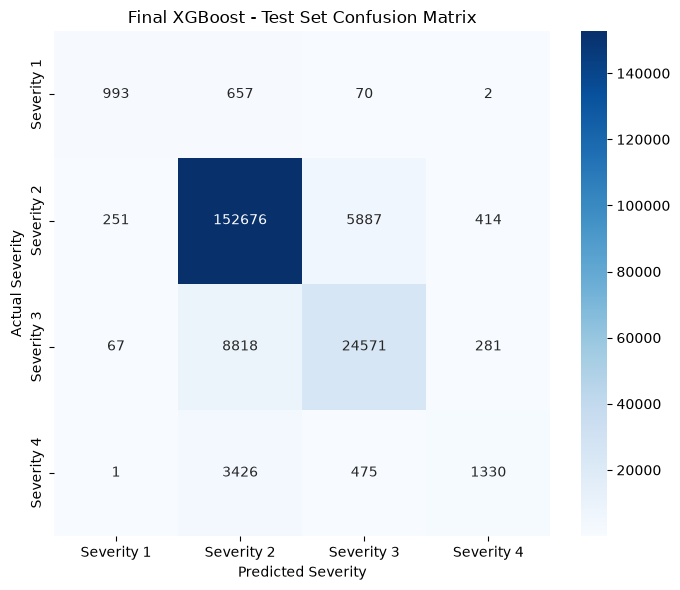

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Severity 1", "Severity 2", "Severity 3", "Severity 4"],
    yticklabels=["Severity 1", "Severity 2", "Severity 3", "Severity 4"]
)

plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title("Final XGBoost - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
final_test_results = pd.DataFrame({
    "Model": ["XGBoost - Optimized - Final Test"],
    "Accuracy": [final_accuracy],
    "Macro Precision": [final_macro_precision],
    "Macro Recall": [final_macro_recall],
    "Macro F1": [final_macro_f1],
    "Weighted F1": [final_weighted_f1]
})

final_test_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost - Optimized - Final Test,0.898214,0.781906,0.629505,0.68005,0.892085


In [33]:
final_test_results.to_csv(
    "../data/final_model_test_results.csv",
    index=False
)

print("Saved: ../data/final_model_test_results.csv")

Saved: ../data/final_model_test_results.csv


## Stage 7 Final Conclusion

In [34]:
print(f"""
STAGE 7 FINAL CONCLUSION
========================

Hyperparameter optimization was performed for Random Forest and XGBoost
using Macro F1 as the primary optimization metric because the target
variable is highly imbalanced.

Both models improved after optimization.
Random Forest Macro F1 increased from {rf_baseline['Macro F1']:.4f} to {rf_macro_f1:.4f} (+{rf_improvement:.4f}).
XGBoost Macro F1 increased from {xgb_baseline['Macro F1']:.4f} to {xgb_macro_f1:.4f} (+{xgb_improvement:.4f}).

The best validation candidate was: {best_model_name}

On the final test dataset, the optimized XGBoost model achieved:
- Accuracy:         {final_accuracy:.4f}
- Macro Precision:  {final_macro_precision:.4f}
- Macro Recall:     {final_macro_recall:.4f}
- Macro F1:         {final_macro_f1:.4f}
- Weighted F1:      {final_weighted_f1:.4f}

The final test Macro F1 ({final_macro_f1:.4f}) was close to the validation
Macro F1 ({xgb_macro_f1:.4f}), indicating the model generalized well to
unseen test data.

The model performed strongest on Severity 2, while Severity 4 remained
the most difficult class to predict, reflecting the strong class
imbalance in the dataset.

Therefore, optimized XGBoost was selected as the final model.
""")


STAGE 7 FINAL CONCLUSION

Hyperparameter optimization was performed for Random Forest and XGBoost
using Macro F1 as the primary optimization metric because the target
variable is highly imbalanced.

Both models improved after optimization.
Random Forest Macro F1 increased from 0.6475 to 0.6721 (+0.0246).
XGBoost Macro F1 increased from 0.6483 to 0.6750 (+0.0268).

The best validation candidate was: XGBoost - Optimized

On the final test dataset, the optimized XGBoost model achieved:
- Accuracy:         0.8982
- Macro Precision:  0.7819
- Macro Recall:     0.6295
- Macro F1:         0.6800
- Weighted F1:      0.8921

The final test Macro F1 (0.6800) was close to the validation
Macro F1 (0.6750), indicating the model generalized well to
unseen test data.

The model performed strongest on Severity 2, while Severity 4 remained
the most difficult class to predict, reflecting the strong class
imbalance in the dataset.

Therefore, optimized XGBoost was selected as the final model.

